Importación de paquetes necesarios

In [46]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

Importación de los dataframes curados con los compuestos y sus respectivos features

In [3]:
df_fisico = pd.read_csv('../data/processed/fisicoquimicos_filtrados.csv')
df_maccs = pd.read_csv('../data/processed/maccs_filtrados.csv')

Separamos las variables independientes (X) y la variable objetivo (y). La columna 'y' (pChEMBL_Value) es exactamente igual en ambos datasets, por lo que con importar una ya será suficiente.

In [4]:
y = df_maccs['pChEMBL_Value'].values
X_fisico = df_fisico.drop(columns=['pChEMBL_Value']).values
X_maccs = df_maccs.drop(columns=['pChEMBL_Value']).values

División Train/Test (80/20). Usamos el mismo random_state=42 para garantizar que las mismas moléculas caigan en Test para ambos modelos

In [5]:
X_train_fisiq, X_test_fisiq, y_train, y_test = train_test_split(X_fisico, y, test_size=0.2, random_state=42)
X_train_mac, X_test_mac, y_train, y_test = train_test_split(X_maccs, y, test_size=0.2, random_state=42)

Definimos y entrenamos los dos modelos Random Forest:

In [6]:
rf_fisico = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_fisico.fit(X_train_fisiq, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [7]:
rf_maccs = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_maccs.fit(X_train_mac, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Generamos las predicciones en el conjunto de prueba:

In [8]:
y_pred_fisico = rf_fisico.predict(X_test_fisiq)
y_pred_maccs = rf_maccs.predict(X_test_mac)

Evaluamos y comparamos los modelos independientes:

In [9]:
print("\n--- RENDIMIENTO: MODELO FISICOQUÍMICO ---")
print(f"R2 Score: {r2_score(y_test, y_pred_fisico):.3f}")
print(f"RMSE:     {np.sqrt(mean_squared_error(y_test, y_pred_fisico)):.3f}")


--- RENDIMIENTO: MODELO FISICOQUÍMICO ---
R2 Score: 0.499
RMSE:     0.606


In [10]:
print("\n--- RENDIMIENTO: MODELO MACCS KEYS ---")
print(f"R2 Score: {r2_score(y_test, y_pred_maccs):.3f}")
print(f"RMSE:     {np.sqrt(mean_squared_error(y_test, y_pred_maccs)):.3f}")


--- RENDIMIENTO: MODELO MACCS KEYS ---
R2 Score: 0.592
RMSE:     0.547


Estrategia de Consenso: Promediamos las predicciones de ambos modelos

In [11]:
y_pred_consenso = (y_pred_fisico + y_pred_maccs) / 2

print("\n--- RENDIMIENTO: MODELO DE CONSENSO (FISICO + MACCS) ---")
print(f"R2 Score: {r2_score(y_test, y_pred_consenso):.3f}")
print(f"RMSE:     {np.sqrt(mean_squared_error(y_test, y_pred_consenso)):.3f}")


--- RENDIMIENTO: MODELO DE CONSENSO (FISICO + MACCS) ---
R2 Score: 0.584
RMSE:     0.552


Let's visualise the true vs the predicted values.

<Axes: xlabel='True', ylabel='Predicted'>

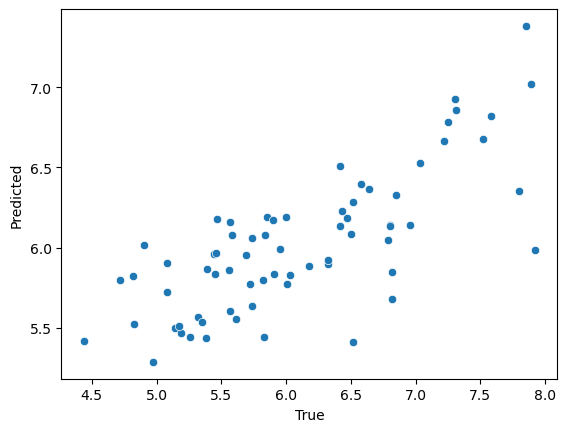

In [12]:
pred_fisico_df = pd.DataFrame(
    {'True': y_test,
     'Predicted': y_pred_fisico
     }
)
sns.scatterplot(data=pred_fisico_df, x="True", y="Predicted")

<Axes: xlabel='True', ylabel='Predicted'>

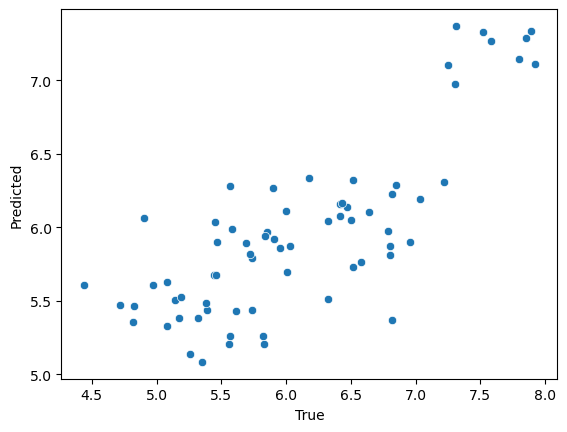

In [13]:
pred_maccs_df = pd.DataFrame(
    {'True': y_test,
     'Predicted': y_pred_maccs
     }
)
sns.scatterplot(data=pred_maccs_df, x="True", y="Predicted")

<Axes: xlabel='True', ylabel='Predicted'>

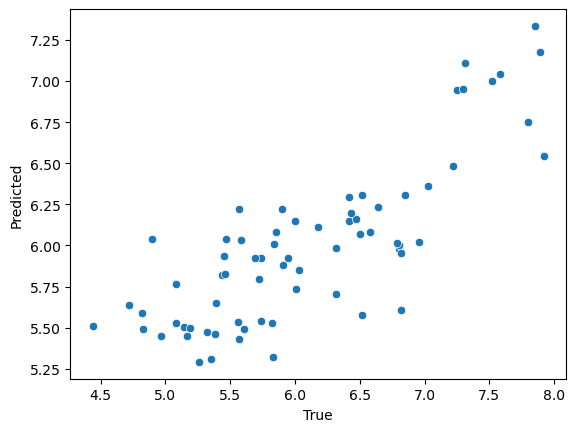

In [14]:
pred_consenso_df = pd.DataFrame(
    {'True': y_test,
     'Predicted': y_pred_consenso
     }
)
sns.scatterplot(data=pred_consenso_df, x="True", y="Predicted")

We are going to use a Random Forest Classifier to classify mitochondiral toxicity. We will
perform a 5 fold grid search cross validation to optimise the parameters of the Classifier.
We can choose between 200 and 300 trees, maximum features to be used in these trees, the
minimum samples to split a node, the maximum depth of a tree.
The taining data will be split into 5 groups and 4 of these will be trained on models varying
these parameters. This will be repeated 5 times and the best performing model's parameters are
stored in the best_estimator

In [33]:
# 1. Definimos la cuadrícula de hiperparámetros a optimizar (param_grid)
param_grid = {
    "n_estimators": [200, 300],              # Evaluamos si necesitas un bosque estándar o más denso
    "max_features": ['sqrt', 'log2'],
    "min_samples_split": [2, 5],              # Control básico de ramificación
    "min_samples_leaf": [1, 2],               # Control básico de sobreajuste en las hojas
    "max_depth": [None, 10, 15],              # Puntos clave de profundidad
    'bootstrap': [True]                       # Mantenerlo True suele ser lo mejor en QSAR pequeños
}

In [34]:
# 2. Configuramos el Grid Search con 5-Fold Cross Validation para el modelo Fisicoquímico
print("Optimizando modelo Fisicoquímico (probando combinaciones)...")
grid_fisico = GridSearchCV(estimator=RandomForestRegressor(random_state=42), 
                           param_grid=param_grid, 
                           cv=5,  
                           n_jobs=-1,  
                           verbose=1) 
grid_fisico.fit(X_train_fisiq, y_train)

Optimizando modelo Fisicoquímico (probando combinaciones)...
Fitting 5 folds for each of 48 candidates, totalling 240 fits


,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'bootstrap': [True], 'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2], ...}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,300


In [35]:
# 3. Configuramos el Grid Search para el modelo MACCS Keys
print("\nOptimizando modelo MACCS Keys (probando combinaciones)...")
grid_maccs = GridSearchCV(estimator=RandomForestRegressor(random_state=42), 
                          param_grid=param_grid, 
                          cv=5, 
                          n_jobs=-1, 
                          verbose=1)
grid_maccs.fit(X_train_mac, y_train)


Optimizando modelo MACCS Keys (probando combinaciones)...
Fitting 5 folds for each of 48 candidates, totalling 240 fits


,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'bootstrap': [True], 'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2], ...}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,300


In [36]:
# 4. Extraemos los mejores hiperparámetros encontrados para cada modelo
print("\nMejores hiperparámetros Fisicoquímicos:", grid_fisico.best_params_)
print("Mejores hiperparámetros MACCS:", grid_maccs.best_params_)


Mejores hiperparámetros Fisicoquímicos: {'bootstrap': True, 'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Mejores hiperparámetros MACCS: {'bootstrap': True, 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}


In [38]:
# 5. Extraemos los modelos ya optimizados automáticamente por Grid Search
best_rf_fisico = grid_fisico.best_estimator_
best_rf_maccs = grid_maccs.best_estimator_

In [39]:
# 6. Generamos las nuevas predicciones optimizadas aplicándolas a los datos de Prueba (Test)
y_pred_fisico_opt = best_rf_fisico.predict(X_test_fisiq)
y_pred_maccs_opt = best_rf_maccs.predict(X_test_mac)

In [40]:
# 7. Calculamos el nuevo Consenso (promedio de las predicciones de los mejores modelos)
y_pred_consenso_opt = (y_pred_fisico_opt + y_pred_maccs_opt) / 2

In [41]:
# 8. Evaluamos el Consenso Final de los modelos Optimizados
print("\n--- RENDIMIENTO: MODELO FISICOQUÍMICO ---")
print(f"R2 Score: {r2_score(y_test, y_pred_fisico_opt):.3f}")
print(f"RMSE:     {np.sqrt(mean_squared_error(y_test, y_pred_fisico_opt)):.3f}")

print("\n--- RENDIMIENTO: MODELO MACCS KEYS ---")
print(f"R2 Score: {r2_score(y_test, y_pred_maccs_opt):.3f}")
print(f"RMSE:     {np.sqrt(mean_squared_error(y_test, y_pred_maccs_opt)):.3f}")

print("\n--- RENDIMIENTO: MODELO CONSENSO OPTIMIZADO ---")
print(f"R2 Score: {r2_score(y_test, y_pred_consenso_opt):.3f}")
print(f"RMSE:     {np.sqrt(mean_squared_error(y_test, y_pred_consenso_opt)):.3f}")


--- RENDIMIENTO: MODELO FISICOQUÍMICO ---
R2 Score: 0.494
RMSE:     0.609

--- RENDIMIENTO: MODELO MACCS KEYS ---
R2 Score: 0.543
RMSE:     0.579

--- RENDIMIENTO: MODELO CONSENSO OPTIMIZADO ---
R2 Score: 0.543
RMSE:     0.579


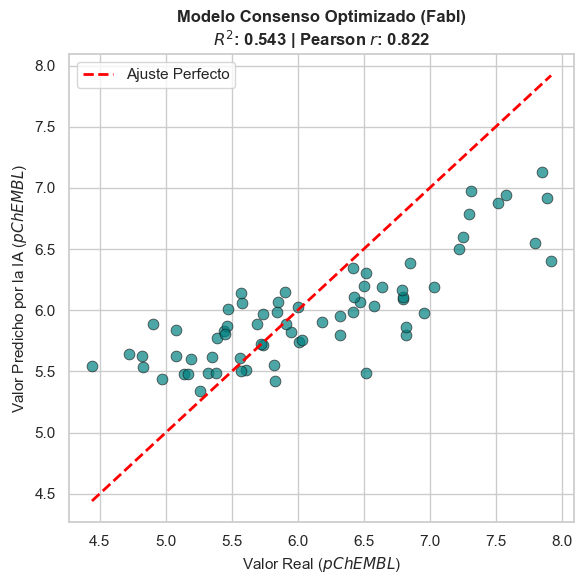

In [47]:
# 1. Configuramos el estilo de la gráfica
sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 6))

# 2. Dibujamos los puntos (Real vs Predicho del Consenso)
sns.scatterplot(x=y_test, y=y_pred_consenso_opt, alpha=0.7, color='teal', edgecolor='k', s=60)

# 3. Dibujamos la línea de ajuste perfecto (diagonal)
p1 = max(max(y_test), max(y_pred_consenso_opt))
p2 = min(min(y_test), min(y_pred_consenso_opt))
plt.plot([p2, p1], [p2, p1], color='red', linestyle='--', linewidth=2, label="Ajuste Perfecto")

# 4. Calculamos la correlación de Pearson para la gráfica
r_val, _ = pearsonr(y_test, y_pred_consenso_opt)

# 5. Títulos y etiquetas (Aseguramos que muestre tu R² real de 0.543)
plt.title(f"Modelo Consenso Optimizado (FabI)\n$R^2$: {0.543:.3f} | Pearson $r$: {r_val:.3f}", fontsize=12, fontweight='bold')
plt.xlabel("Valor Real ($pChEMBL$)", fontsize=11)
plt.ylabel("Valor Predicho por la IA ($pChEMBL$)", fontsize=11)
plt.legend(loc="upper left")

# 6. Ajustamos márgenes y guardamos
plt.tight_layout()
plt.savefig("correlacion_consenso_qsar.png", dpi=300)
plt.show()